In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("D:\Projects\Amazon Data Analysis\Amazon Cleaned Data.xlsx")

df['OrderDate'] = pd.to_datetime(df['OrderDate'])

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [3]:
df.shape

(100000, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  object        
 1   OrderDate      100000 non-null  datetime64[ns]
 2   CustomerID     100000 non-null  object        
 3   CustomerName   100000 non-null  object        
 4   ProductID      100000 non-null  object        
 5   ProductName    100000 non-null  object        
 6   Category       100000 non-null  object        
 7   Brand          100000 non-null  object        
 8   Quantity       100000 non-null  int64         
 9   UnitPrice      100000 non-null  float64       
 10  Discount       100000 non-null  float64       
 11  Tax            100000 non-null  float64       
 12  ShippingCost   100000 non-null  float64       
 13  TotalAmount    100000 non-null  float64       
 14  PaymentMethod  100000 non-null  object        
 15  O

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [6]:
reference_date = df['OrderDate'].max()

print(reference_date)

2024-12-29 00:00:00


In [9]:
rfm = (
    df.groupby('CustomerID')
      .agg({
          'OrderDate': lambda x: (reference_date - x.max()).days,
          'OrderID': 'nunique',
          'TotalAmount': 'sum'
      })
      .reset_index()
)

In [10]:
rfm.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]

In [11]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,CUST000001,156,1,446.48
1,CUST000002,1062,3,1389.93
2,CUST000003,1462,1,1116.91
3,CUST000004,195,3,2660.06
4,CUST000005,639,1,1089.56


In [12]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43233 entries, 0 to 43232
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  43233 non-null  object 
 1   Recency     43233 non-null  int64  
 2   Frequency   43233 non-null  int64  
 3   Monetary    43233 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 1.3+ MB


In [13]:
rfm.describe()

,Recency,Frequency,Monetary
count,43233.000000,43233.000000,43233.000000
mean,627.165499,2.313048,2123.971224
std,478.122067,1.257115,1594.379364
min,0.000000,1.000000,6.190000
25%,224.000000,1.000000,876.190000
50%,518.000000,2.000000,1805.410000
75%,953.000000,3.000000,2992.430000
max,1824.000000,10.000000,15215.790000


In [14]:
rfm['CustomerID'].nunique(), len(rfm)

(43233, 43233)

In [15]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

In [16]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [17]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [18]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,CUST000001,156,1,446.48,5,1,1
1,CUST000002,1062,3,1389.93,2,4,2
2,CUST000003,1462,1,1116.91,1,1,2
3,CUST000004,195,3,2660.06,4,4,4
4,CUST000005,639,1,1089.56,3,1,2


In [19]:
rfm[['R_Score', 'F_Score', 'M_Score']].describe()

,R_Score,F_Score,M_Score
count,43233,43233,43233
unique,5,5,5
top,3,1,1
freq,8656,8647,8647


In [20]:
rfm[['R_Score', 'F_Score', 'M_Score']].value_counts()

R_Score  F_Score  M_Score
5        5        5          1843
1        1        1          1759
4        5        5          1514
1        2        1          1078
3        5        5          1028
                             ... 
2        1        5             2
1        1        5             2
         5        1             2
3        1        5             1
4        1        5             1
Name: count, Length: 124, dtype: int64

In [21]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [22]:
rfm[['CustomerID','RFM_Score']].head()

,CustomerID,RFM_Score
0,CUST000001,511
1,CUST000002,242
2,CUST000003,112
3,CUST000004,444
4,CUST000005,312


In [23]:
rfm['RFM_Total'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

In [24]:
def customer_segment(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential Loyalists"
    elif score >= 4:
        return "At Risk"
    else:
        return "Lost Customers"

rfm['Customer_Segment'] = rfm['RFM_Total'].apply(customer_segment)

In [25]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Customer_Segment
0,CUST000001,156,1,446.48,5,1,1,511,7,Potential Loyalists
1,CUST000002,1062,3,1389.93,2,4,2,242,8,Potential Loyalists
2,CUST000003,1462,1,1116.91,1,1,2,112,4,At Risk
3,CUST000004,195,3,2660.06,4,4,4,444,12,Loyal Customers
4,CUST000005,639,1,1089.56,3,1,2,312,6,At Risk


In [26]:
segment_summary = (
    rfm['Customer_Segment']
    .value_counts()
    .reset_index()
)

segment_summary.columns = ['Customer_Segment', 'Customer_Count']

segment_summary

,Customer_Segment,Customer_Count
0,Potential Loyalists,11854
1,Loyal Customers,11675
2,At Risk,9973
3,Champions,7972
4,Lost Customers,1759


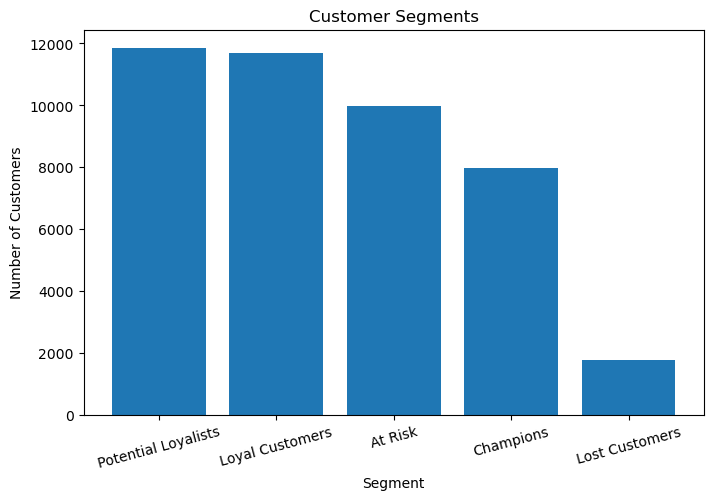

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_summary['Customer_Segment'],
    segment_summary['Customer_Count']
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

### Business Insight

- The majority of customers belong to the **Potential Loyalists** segment.
- **Champions** represent the highest-value customers and should be retained through loyalty programs.
- **At Risk** and **Lost Customers** can be targeted with re-engagement campaigns and personalized offers.

In [28]:
rfm.to_csv("rfm_analysis.csv", index=False)

In [29]:
rfm.sort_values('Monetary', ascending=False).head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Customer_Segment
20573,CUST023748,54,10,15215.79,5,5,5,555,15,Champions
8298,CUST009614,165,9,12160.96,5,5,5,555,15,Champions
29589,CUST034178,45,6,11418.88,5,5,5,555,15,Champions
981,CUST001153,303,9,11282.96,4,5,5,455,14,Champions
4215,CUST004883,86,5,11214.44,5,5,5,555,15,Champions
680,CUST000787,111,7,10962.32,5,5,5,555,15,Champions
13544,CUST015677,15,5,10956.10,5,5,5,555,15,Champions
36956,CUST042689,890,8,10726.80,2,5,5,255,12,Loyal Customers
13164,CUST015231,82,6,10638.79,5,5,5,555,15,Champions
28815,CUST033270,287,5,10593.41,4,5,5,455,14,Champions


In [30]:
rfm[rfm['Customer_Segment']=='Champions']

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Customer_Segment
5,CUST000006,248,4,2831.85,4,5,4,454,13,Champions
7,CUST000008,52,3,4116.16,5,4,5,545,14,Champions
10,CUST000011,65,3,2852.02,5,4,4,544,13,Champions
28,CUST000031,260,4,4627.38,4,5,5,455,14,Champions
38,CUST000044,344,3,3636.77,4,4,5,445,13,Champions
...,...,...,...,...,...,...,...,...,...,...
43207,CUST049970,202,4,2276.49,4,5,4,454,13,Champions
43214,CUST049978,94,5,4399.96,5,5,5,555,15,Champions
43215,CUST049980,14,3,1644.75,5,5,3,553,13,Champions
43223,CUST049989,518,4,3533.42,3,5,5,355,13,Champions


In [31]:
rfm.groupby('Customer_Segment')['Monetary'].mean().sort_values(ascending=False)

Customer_Segment
Champions              4222.963034
Loyal Customers        2633.029040
Potential Loyalists    1541.933224
At Risk                 856.484175
Lost Customers          340.977516
Name: Monetary, dtype: float64

In [32]:
rfm.groupby('Customer_Segment')['Recency'].mean()

Customer_Segment
At Risk                1047.418229
Champions               202.801681
Lost Customers         1444.010802
Loyal Customers         433.867409
Potential Loyalists     628.158596
Name: Recency, dtype: float64

In [33]:
rfm.groupby('Customer_Segment')['Frequency'].mean()

Customer_Segment
At Risk                1.183094
Champions              4.047040
Lost Customers         1.000000
Loyal Customers        2.791092
Potential Loyalists    1.821579
Name: Frequency, dtype: float64

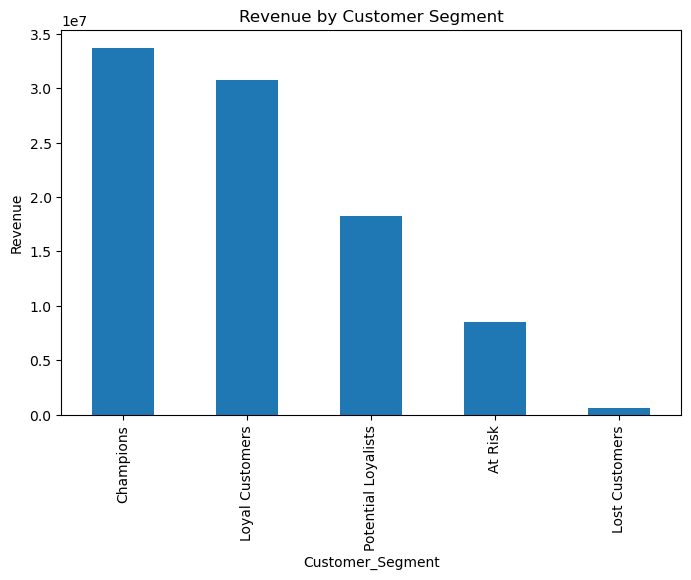

In [34]:
segment_revenue = (
    rfm.groupby('Customer_Segment')['Monetary']
       .sum()
       .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

segment_revenue.plot(kind='bar')

plt.title("Revenue by Customer Segment")
plt.ylabel("Revenue")

plt.show()

In [35]:
rfm_ml = rfm[['Recency', 'Frequency', 'Monetary']].copy()

rfm_ml.head()

,Recency,Frequency,Monetary
0,156,1,446.48
1,1062,3,1389.93
2,1462,1,1116.91
3,195,3,2660.06
4,639,1,1089.56


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_ml)

In [37]:
rfm_scaled[:5]

array([[-0.98546162, -1.0445049 , -1.0521402 ],
       [ 0.90947388,  0.54645747, -0.4603984 ],
       [ 1.74608999, -1.0445049 , -0.63163943],
       [-0.90389155,  0.54645747,  0.33624054],
       [ 0.02475234, -1.0445049 , -0.64879364]])

In [38]:
rfm_scaled.shape

(43233, 3)

In [39]:
from sklearn.cluster import KMeans

In [40]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

  File "c:\Users\Pranav\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Pranav\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Pranav\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Pranav\anaconda3\Lib\subproc

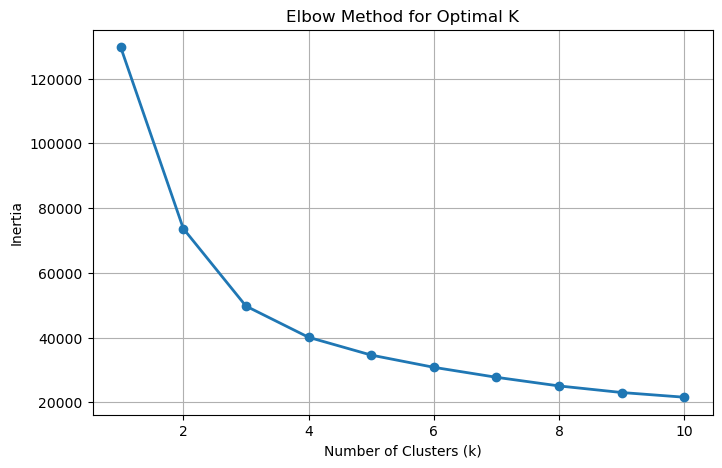

In [41]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.grid(True)

plt.show()

### Choosing the Optimal Number of Clusters

The Elbow Method was used to determine the optimal number of customer clusters.

The inertia decreased rapidly from k = 1 to k = 4 and then started to flatten, indicating diminishing returns from adding more clusters.

Therefore, **4 clusters** were selected as the optimal value for K-Means clustering.

In [42]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(rfm_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [43]:
rfm['Cluster'] = kmeans.labels_

In [44]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Customer_Segment,Cluster
0,CUST000001,156,1,446.48,5,1,1,511,7,Potential Loyalists,2
1,CUST000002,1062,3,1389.93,2,4,2,242,8,Potential Loyalists,1
2,CUST000003,1462,1,1116.91,1,1,2,112,4,At Risk,1
3,CUST000004,195,3,2660.06,4,4,4,444,12,Loyal Customers,0
4,CUST000005,639,1,1089.56,3,1,2,312,6,At Risk,2


In [45]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    13210
1    11520
2    13263
3     5240
Name: count, dtype: int64

In [46]:
cluster_summary = (
    rfm.groupby('Cluster')
       .agg({
           'Recency': 'mean',
           'Frequency': 'mean',
           'Monetary': 'mean'
       })
       .round(2)
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,415.50,2.96,2781.52
1,1276.83,1.40,1215.25
2,392.78,1.57,1088.32
3,325.77,4.55,5085.47


In [47]:
cluster_names = {
    0: "Regular Customers",
    1: "Inactive Customers",
    2: "Occasional Customers",
    3: "High Value Customers"
}

rfm["Customer_Cluster"] = rfm["Cluster"].map(cluster_names)

In [48]:
rfm[['CustomerID', 'Cluster', 'Customer_Cluster']].head()

,CustomerID,Cluster,Customer_Cluster
0,CUST000001,2,Occasional Customers
1,CUST000002,1,Inactive Customers
2,CUST000003,1,Inactive Customers
3,CUST000004,0,Regular Customers
4,CUST000005,2,Occasional Customers


In [49]:
cluster_distribution = (
    rfm['Customer_Cluster']
       .value_counts()
       .reset_index()
)

cluster_distribution.columns = ['Customer_Cluster', 'Customer_Count']

cluster_distribution

,Customer_Cluster,Customer_Count
0,Occasional Customers,13263
1,Regular Customers,13210
2,Inactive Customers,11520
3,High Value Customers,5240


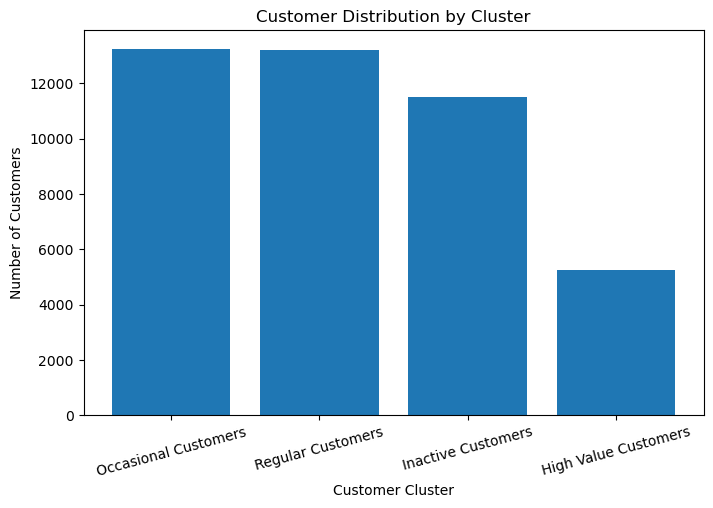

In [50]:
plt.figure(figsize=(8,5))

plt.bar(
    cluster_distribution['Customer_Cluster'],
    cluster_distribution['Customer_Count']
)

plt.title("Customer Distribution by Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

In [51]:
rfm.to_csv("customer_segments.csv", index=False)

## Business Insights - Customer Segmentation

- High Value Customers have the highest purchase frequency and spending. These customers should be prioritized through loyalty programs and premium services.
- Regular Customers contribute consistent revenue and can be targeted with cross-selling and upselling campaigns.
- Occasional Customers purchase infrequently and have lower spending. Personalized discounts may encourage repeat purchases.
- Inactive Customers have not purchased for a long time and represent an opportunity for re-engagement through win-back campaigns.

In [52]:
product_sales = (
    df.groupby('ProductName')['TotalAmount']
      .sum()
      .reset_index()
)

product_sales.head()

,ProductName,TotalAmount
0,4K Monitor,1866774.35
1,Action Camera,1829029.24
2,Air Fryer,1789927.34
3,Backpack,1749971.14
4,Bluetooth Speaker,1803356.76


In [53]:
product_sales = product_sales.sort_values(
    by='TotalAmount',
    ascending=False
)

product_sales.head()

,ProductName,TotalAmount
25,Memory Card 128GB,1935138.40
22,LED Desk Lamp,1921948.41
24,Mechanical Keyboard,1906963.54
13,Electric Kettle,1905751.79
39,Smartwatch,1901275.59


In [54]:
total_revenue = product_sales['TotalAmount'].sum()

product_sales['Revenue_Percentage'] = (
    product_sales['TotalAmount'] / total_revenue
) * 100

In [55]:
product_sales['Cumulative_Percentage'] = (
    product_sales['Revenue_Percentage']
    .cumsum()
)

In [56]:
product_sales.head(10)

,ProductName,TotalAmount,Revenue_Percentage,Cumulative_Percentage
25,Memory Card 128GB,1935138.40,2.107405,2.107405
22,LED Desk Lamp,1921948.41,2.093041,4.200446
24,Mechanical Keyboard,1906963.54,2.076722,6.277168
13,Electric Kettle,1905751.79,2.075402,8.352571
39,Smartwatch,1901275.59,2.070528,10.423098
11,Dress Shirt,1896765.36,2.065616,12.488715
44,Water Bottle,1895467.95,2.064203,14.552918
16,Gaming Mouse,1895103.98,2.063807,16.616725
21,Kids Toy Car,1891082.43,2.059427,18.676152
20,Jeans,1882591.82,2.050181,20.726333


In [57]:
product_sales.head(10)

,ProductName,TotalAmount,Revenue_Percentage,Cumulative_Percentage
25,Memory Card 128GB,1935138.40,2.107405,2.107405
22,LED Desk Lamp,1921948.41,2.093041,4.200446
24,Mechanical Keyboard,1906963.54,2.076722,6.277168
13,Electric Kettle,1905751.79,2.075402,8.352571
39,Smartwatch,1901275.59,2.070528,10.423098
11,Dress Shirt,1896765.36,2.065616,12.488715
44,Water Bottle,1895467.95,2.064203,14.552918
16,Gaming Mouse,1895103.98,2.063807,16.616725
21,Kids Toy Car,1891082.43,2.059427,18.676152
20,Jeans,1882591.82,2.050181,20.726333


In [58]:
def abc_category(cumulative):
    if cumulative <= 80:
        return 'A'
    elif cumulative <= 95:
        return 'B'
    else:
        return 'C'

product_sales['ABC_Category'] = product_sales['Cumulative_Percentage'].apply(abc_category)

In [59]:
product_sales.head(15)

,ProductName,TotalAmount,Revenue_Percentage,Cumulative_Percentage,ABC_Category
25,Memory Card 128GB,1935138.40,2.107405,2.107405,A
22,LED Desk Lamp,1921948.41,2.093041,4.200446,A
24,Mechanical Keyboard,1906963.54,2.076722,6.277168,A
13,Electric Kettle,1905751.79,2.075402,8.352571,A
39,Smartwatch,1901275.59,2.070528,10.423098,A
11,Dress Shirt,1896765.36,2.065616,12.488715,A
44,Water Bottle,1895467.95,2.064203,14.552918,A
16,Gaming Mouse,1895103.98,2.063807,16.616725,A
21,Kids Toy Car,1891082.43,2.059427,18.676152,A
20,Jeans,1882591.82,2.050181,20.726333,A


In [60]:
abc_summary = (
    product_sales['ABC_Category']
        .value_counts()
        .reset_index()
)

abc_summary.columns = ['ABC_Category', 'Product_Count']

abc_summary

,ABC_Category,Product_Count
0,A,39
1,B,8
2,C,3


In [61]:
abc_revenue = (
    product_sales.groupby('ABC_Category')['TotalAmount']
                 .sum()
                 .reset_index()
)

abc_revenue

,ABC_Category,TotalAmount
0,A,72312096.77
1,B,14265794.82
2,C,5247756.33


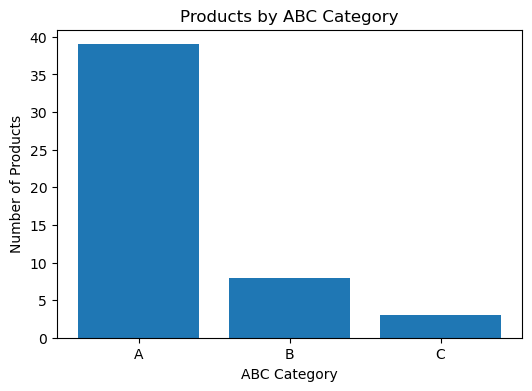

In [62]:
plt.figure(figsize=(6,4))

plt.bar(
    abc_summary['ABC_Category'],
    abc_summary['Product_Count']
)

plt.title("Products by ABC Category")
plt.xlabel("ABC Category")
plt.ylabel("Number of Products")

plt.show()

In [63]:
product_sales.to_csv("abc_analysis.csv", index=False)

## Business Insights - ABC Analysis

- Category A products contribute the largest share of revenue and should receive the highest inventory priority.
- Category B products generate moderate revenue and require regular monitoring.
- Category C products contribute the least revenue and can be reviewed for inventory optimization or promotional strategies.

## Validation of ABC Analysis

In [64]:
abc_validation = (
    product_sales.groupby('ABC_Category')
                 .agg(
                     Products=('ProductName','count'),
                     Revenue=('TotalAmount','sum')
                 )
                 .reset_index()
)

In [65]:
abc_validation['Revenue_Percentage'] = (
    abc_validation['Revenue']
    / abc_validation['Revenue'].sum()
) * 100

In [ ]:
abc_validation['Revenue_Percentage'] = (
    abc_validation['Revenue_Percentage']
    .round(2)
)

In [66]:
abc_validation

,ABC_Category,Products,Revenue,Revenue_Percentage
0,A,39,72312096.77,78.749346
1,B,8,14265794.82,15.535741
2,C,3,5247756.33,5.714913


# Pareto Analysis

## Business Objective

Pareto Analysis helps identify the products that contribute the largest share of total revenue.

The analysis is based on the Pareto Principle (80/20 Rule), which suggests that a small percentage of products often generate the majority of business revenue.

This analysis supports inventory planning, product prioritization, and marketing strategy.

In [67]:
pareto = product_sales.copy()

In [68]:
pareto = pareto.sort_values(
    by='TotalAmount',
    ascending=False
)

In [69]:
pareto['Rank'] = range(1, len(pareto) + 1)

In [70]:
pareto['Cumulative_Revenue'] = (
    pareto['TotalAmount']
    .cumsum()
)

In [71]:
total_revenue = pareto['TotalAmount'].sum()

pareto['Cumulative_Revenue_%'] = (
    pareto['Cumulative_Revenue']
    / total_revenue
) * 100

In [72]:
pareto.head(10)

,ProductName,TotalAmount,Revenue_Percentage,Cumulative_Percentage,ABC_Category,Rank,Cumulative_Revenue,Cumulative_Revenue_%
25,Memory Card 128GB,1935138.40,2.107405,2.107405,A,1,1935138.40,2.107405
22,LED Desk Lamp,1921948.41,2.093041,4.200446,A,2,3857086.81,4.200446
24,Mechanical Keyboard,1906963.54,2.076722,6.277168,A,3,5764050.35,6.277168
13,Electric Kettle,1905751.79,2.075402,8.352571,A,4,7669802.14,8.352571
39,Smartwatch,1901275.59,2.070528,10.423098,A,5,9571077.73,10.423098
11,Dress Shirt,1896765.36,2.065616,12.488715,A,6,11467843.09,12.488715
44,Water Bottle,1895467.95,2.064203,14.552918,A,7,13363311.04,14.552918
16,Gaming Mouse,1895103.98,2.063807,16.616725,A,8,15258415.02,16.616725
21,Kids Toy Car,1891082.43,2.059427,18.676152,A,9,17149497.45,18.676152
20,Jeans,1882591.82,2.050181,20.726333,A,10,19032089.27,20.726333


In [73]:
top_products = pareto[
    pareto['Cumulative_Revenue_%'] <= 80
]

top_products

,ProductName,TotalAmount,Revenue_Percentage,Cumulative_Percentage,ABC_Category,Rank,Cumulative_Revenue,Cumulative_Revenue_%
25,Memory Card 128GB,1935138.40,2.107405,2.107405,A,1,1935138.40,2.107405
22,LED Desk Lamp,1921948.41,2.093041,4.200446,A,2,3857086.81,4.200446
24,Mechanical Keyboard,1906963.54,2.076722,6.277168,A,3,5764050.35,6.277168
13,Electric Kettle,1905751.79,2.075402,8.352571,A,4,7669802.14,8.352571
39,Smartwatch,1901275.59,2.070528,10.423098,A,5,9571077.73,10.423098
11,Dress Shirt,1896765.36,2.065616,12.488715,A,6,11467843.09,12.488715
44,Water Bottle,1895467.95,2.064203,14.552918,A,7,13363311.04,14.552918
16,Gaming Mouse,1895103.98,2.063807,16.616725,A,8,15258415.02,16.616725
21,Kids Toy Car,1891082.43,2.059427,18.676152,A,9,17149497.45,18.676152
20,Jeans,1882591.82,2.050181,20.726333,A,10,19032089.27,20.726333


In [74]:
print("Products contributing to 80% revenue:", len(top_products))

Products contributing to 80% revenue: 39


In [75]:
print(
    round(
        len(top_products) / len(pareto) * 100,
        2
    ),
    "% of products generate 80% of revenue."
)

78.0 % of products generate 80% of revenue.


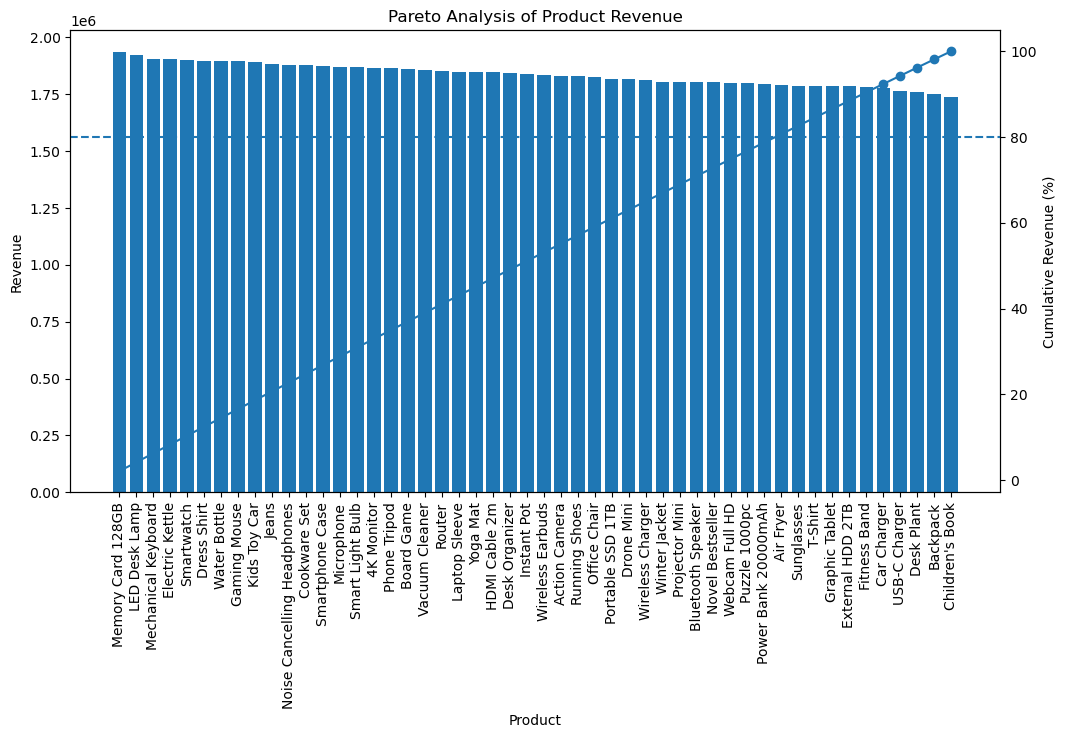

In [76]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Revenue bars
ax1.bar(
    pareto['ProductName'],
    pareto['TotalAmount']
)

ax1.set_ylabel("Revenue")
ax1.set_xlabel("Product")
ax1.tick_params(axis='x', rotation=90)

# Cumulative percentage line
ax2 = ax1.twinx()

ax2.plot(
    pareto['ProductName'],
    pareto['Cumulative_Revenue_%'],
    marker='o'
)

ax2.set_ylabel("Cumulative Revenue (%)")
ax2.axhline(80, linestyle='--')

plt.title("Pareto Analysis of Product Revenue")

plt.show()

In [77]:
pareto.to_csv("pareto_analysis.csv", index=False)

## Business Insights - Pareto Analysis

- A relatively small number of products contribute to the majority of total revenue.
- These products should receive the highest priority for inventory management, pricing strategies, and promotional campaigns.
- Products beyond the 80% cumulative revenue threshold contribute less and may require different inventory and marketing strategies.

# Sales Forecasting

## Business Objective

Forecast future monthly sales using historical transaction data.

The forecast supports inventory planning, budgeting, workforce planning, and business strategy.

In [78]:
monthly_sales = (
    df.groupby(pd.Grouper(key='OrderDate', freq='M'))
      .agg({'TotalAmount': 'sum'})
      .reset_index()
)

In [79]:
monthly_sales.head()

,OrderDate,TotalAmount
0,2020-01-31,1637069.40
1,2020-02-29,1339388.21
2,2020-03-31,1587125.66
3,2020-04-30,1588347.29
4,2020-05-31,1533834.17


In [80]:
forecast_data = monthly_sales.rename(
    columns={
        'OrderDate':'ds',
        'TotalAmount':'y'
    }
)

In [81]:
forecast_data.head()

,ds,y
0,2020-01-31,1637069.40
1,2020-02-29,1339388.21
2,2020-03-31,1587125.66
3,2020-04-30,1588347.29
4,2020-05-31,1533834.17


In [82]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [83]:
from prophet import Prophet

In [84]:
model = Prophet()

model.fit(forecast_data)

16:40:22 - cmdstanpy - INFO - Chain [1] start processing
16:40:24 - cmdstanpy - INFO - Chain [1] done processing


In [85]:
future = model.make_future_dataframe(
    periods=6,
    freq='M'
)

forecast = model.predict(future)

In [86]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
56,2024-09-30,1.509923e+06,1.460527e+06,1.559860e+06
57,2024-10-31,1.513901e+06,1.464895e+06,1.568798e+06
58,2024-11-30,1.497967e+06,1.448918e+06,1.548239e+06
59,2024-12-31,1.515350e+06,1.466742e+06,1.565413e+06
60,2025-01-31,1.592991e+06,1.546578e+06,1.641564e+06
61,2025-02-28,1.375228e+06,1.327046e+06,1.423048e+06
62,2025-03-31,1.541077e+06,1.490257e+06,1.586790e+06
63,2025-04-30,1.516801e+06,1.465864e+06,1.563661e+06
64,2025-05-31,1.561833e+06,1.510361e+06,1.610778e+06
65,2025-06-30,1.520700e+06,1.470556e+06,1.569174e+06


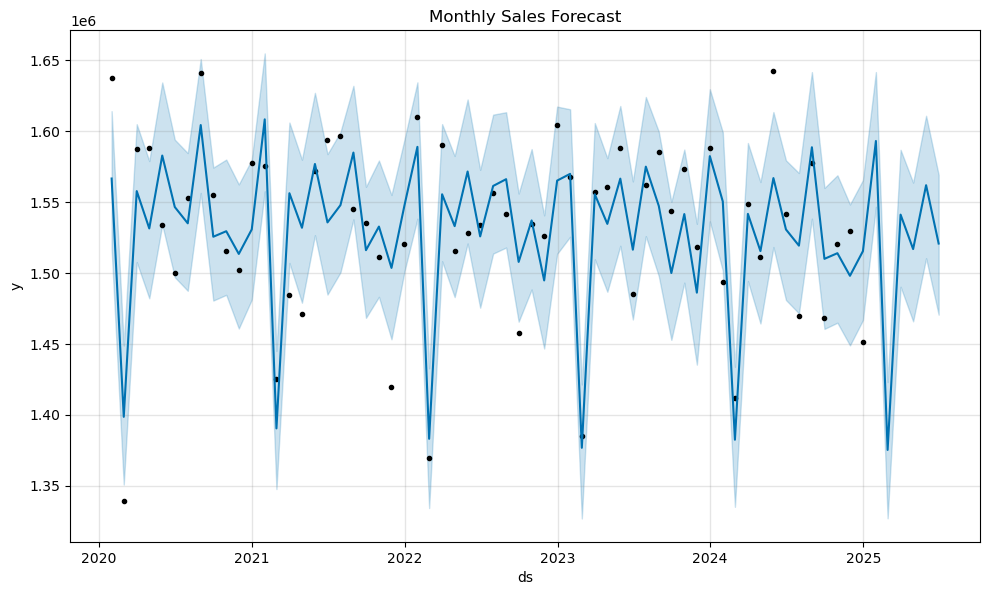

In [87]:
fig = model.plot(forecast)
plt.title("Monthly Sales Forecast")
plt.show()

In [89]:
kpi = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Average Order Value"
    ],
    "Value": [
        df["TotalAmount"].sum(),
        df["OrderID"].nunique(),
        df["CustomerID"].nunique(),
        df["ProductName"].nunique(),
        round(df["TotalAmount"].mean(), 2)
    ]
})

kpi

,Metric,Value
0,Total Revenue,91825647.92
1,Total Orders,100000.00
2,Total Customers,43233.00
3,Total Products,50.00
4,Average Order Value,918.26


In [90]:
kpi.to_csv("kpi_summary.csv", index=False)

# Executive Summary

## Customer Insights
- RFM Analysis identified high-value and inactive customer segments.
- K-Means clustering automatically grouped customers based on purchasing behavior.

## Product Insights
- ABC Analysis classified products according to revenue contribution.
- Pareto Analysis identified the products contributing to the majority of revenue.

## Sales Insights
- Monthly sales forecasting estimated future revenue trends.
- The forecast can support inventory planning and budgeting.

## Business Recommendations
- Retain high-value customers through loyalty programs.
- Re-engage inactive customers with targeted promotions.
- Prioritize Category A products in inventory management.
- Use sales forecasts for inventory and workforce planning.

In [91]:
fact_sales = df[[
    'OrderID',
    'OrderDate',
    'CustomerID',
    'ProductID',
    'Quantity',
    'UnitPrice',
    'Discount',
    'Tax',
    'ShippingCost',
    'TotalAmount',
    'PaymentMethod',
    'OrderStatus',
    'SellerID'
]]

fact_sales.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,SellerID
0,ORD0000001,2023-01-31,CUST001504,P00014,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,SELL01967
1,ORD0000002,2023-12-30,CUST000178,P00040,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,SELL01298
2,ORD0000003,2022-05-10,CUST047516,P00044,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,SELL00908
3,ORD0000004,2023-07-18,CUST030059,P00041,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,SELL01164
4,ORD0000005,2023-02-04,CUST048677,P00029,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,SELL01411


In [93]:
fact_sales.to_csv("Fact_Sales.csv", index=False)

In [94]:
dim_customer = rfm[[
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary',
    'RFM_Score',
    'Customer_Segment',
    'Cluster',
    'Customer_Cluster'
]].copy()

In [95]:
customer_names = (
    df[['CustomerID', 'CustomerName']]
    .drop_duplicates()
)

dim_customer = dim_customer.merge(
    customer_names,
    on='CustomerID',
    how='left'
)

In [96]:
dim_customer = dim_customer[[
    'CustomerID',
    'CustomerName',
    'Recency',
    'Frequency',
    'Monetary',
    'RFM_Score',
    'Customer_Segment',
    'Cluster',
    'Customer_Cluster'
]]

In [97]:
dim_customer.head()

,CustomerID,CustomerName,Recency,Frequency,Monetary,RFM_Score,Customer_Segment,Cluster,Customer_Cluster
0,CUST000001,Sunita Kumar,156,1,446.48,511,Potential Loyalists,2,Occasional Customers
1,CUST000002,Vikas Gupta,1062,3,1389.93,242,Potential Loyalists,1,Inactive Customers
2,CUST000002,Arjun Singh,1062,3,1389.93,242,Potential Loyalists,1,Inactive Customers
3,CUST000002,Ritika Patel,1062,3,1389.93,242,Potential Loyalists,1,Inactive Customers
4,CUST000003,Aditya Gupta,1462,1,1116.91,112,At Risk,1,Inactive Customers


In [99]:
dim_customer.to_csv(
    "Dim_Customer.csv",
    index=False
)

In [100]:
dim_customer.shape

(99500, 9)

In [101]:
dim_customer['CustomerID'].duplicated().sum()

np.int64(56267)

In [102]:
dim_customer.isnull().sum()

CustomerID          0
CustomerName        0
Recency             0
Frequency           0
Monetary            0
RFM_Score           0
Customer_Segment    0
Cluster             0
Customer_Cluster    0
dtype: int64

In [103]:
dim_product = (
    df[[
        'ProductID',
        'ProductName',
        'Category',
        'Brand'
    ]]
    .drop_duplicates()
)

In [104]:
abc_info = product_sales[[
    'ProductName',
    'ABC_Category',
    'Revenue_Percentage',
    'Cumulative_Percentage'
]]

dim_product = dim_product.merge(
    abc_info,
    on='ProductName',
    how='left'
)

In [105]:
dim_product.head()

,ProductID,ProductName,Category,Brand,ABC_Category,Revenue_Percentage,Cumulative_Percentage
0,P00014,Drone Mini,Books,BrightLux,A,1.977882,63.042573
1,P00040,Microphone,Home & Kitchen,UrbanStyle,A,2.038364,28.899767
2,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,A,1.954507,78.749346
3,P00041,Webcam Full HD,Home & Kitchen,Zenith,A,1.959510,74.836984
4,P00029,T-Shirt,Clothing,KiddoFun,B,1.947011,84.592914


In [106]:
dim_product.shape

(3000, 7)

In [107]:
dim_product['ProductID'].duplicated().sum()

np.int64(2950)

In [108]:
dim_product.isnull().sum()

ProductID                0
ProductName              0
Category                 0
Brand                    0
ABC_Category             0
Revenue_Percentage       0
Cumulative_Percentage    0
dtype: int64

In [109]:
dim_product.to_csv(
    "Dim_Product.csv",
    index=False
)

In [110]:
df['OrderDate'].min(), df['OrderDate'].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2024-12-29 00:00:00'))

In [111]:
dim_date = pd.DataFrame({
    'Date': pd.date_range(
        start=df['OrderDate'].min(),
        end=df['OrderDate'].max(),
        freq='D'
    )
})

In [112]:
dim_date['Year'] = dim_date['Date'].dt.year

dim_date['Quarter'] = dim_date['Date'].dt.quarter

dim_date['Month'] = dim_date['Date'].dt.month

dim_date['Month_Name'] = dim_date['Date'].dt.month_name()

dim_date['Week'] = dim_date['Date'].dt.isocalendar().week.astype(int)

dim_date['Day'] = dim_date['Date'].dt.day

dim_date['Day_Name'] = dim_date['Date'].dt.day_name()

dim_date['Day_of_Week'] = dim_date['Date'].dt.dayofweek

In [113]:
dim_date['Is_Weekend'] = dim_date['Day_of_Week'].isin([5, 6])

In [114]:
dim_date['Quarter_Name'] = (
    'Q' + dim_date['Quarter'].astype(str)
)

In [115]:
dim_date['Month_Year'] = (
    dim_date['Date'].dt.strftime('%b-%Y')
)

In [116]:
dim_date.head()

,Date,Year,Quarter,Month,Month_Name,Week,Day,Day_Name,Day_of_Week,Is_Weekend,Quarter_Name,Month_Year
0,2020-01-01,2020,1,1,January,1,1,Wednesday,2,False,Q1,Jan-2020
1,2020-01-02,2020,1,1,January,1,2,Thursday,3,False,Q1,Jan-2020
2,2020-01-03,2020,1,1,January,1,3,Friday,4,False,Q1,Jan-2020
3,2020-01-04,2020,1,1,January,1,4,Saturday,5,True,Q1,Jan-2020
4,2020-01-05,2020,1,1,January,1,5,Sunday,6,True,Q1,Jan-2020


In [117]:
dim_date.shape

(1825, 12)

In [118]:
dim_date.isnull().sum()

Date            0
Year            0
Quarter         0
Month           0
Month_Name      0
Week            0
Day             0
Day_Name        0
Day_of_Week     0
Is_Weekend      0
Quarter_Name    0
Month_Year      0
dtype: int64

In [119]:
dim_date['Date'].duplicated().sum()

np.int64(0)

In [120]:
dim_date.to_csv(
    "Dim_Date.csv",
    index=False
)

In [121]:
forecast_table = forecast[[
    'ds',
    'yhat',
    'yhat_lower',
    'yhat_upper'
]].copy()

In [122]:
forecast_table.columns = [
    'Date',
    'Forecast_Sales',
    'Lower_Bound',
    'Upper_Bound'
]

In [123]:
forecast_table.head()

,Date,Forecast_Sales,Lower_Bound,Upper_Bound
0,2020-01-31,1.566543e+06,1.517119e+06,1.614003e+06
1,2020-02-29,1.398555e+06,1.350845e+06,1.448816e+06
2,2020-03-31,1.557677e+06,1.507655e+06,1.604826e+06
3,2020-04-30,1.531345e+06,1.482105e+06,1.578842e+06
4,2020-05-31,1.582731e+06,1.534042e+06,1.634240e+06


In [124]:
forecast_table.to_csv(
    "Sales_Forecast.csv",
    index=False
)